In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

file_path = '/Users/manuhalapeth/Kenda/SalesData_ATW.xlsx'

xl = pd.ExcelFile(file_path, engine='openpyxl')
sheet_names = xl.sheet_names
print(f"Sheet names: {sheet_names}")
print(f"Number of sheets: {len(sheet_names)}")


Sheet names: ['Sheet1']
Number of sheets: 1


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 40)

for sheet in sheet_names:
    print(f"\n{'='*80}")
    print(f"SHEET: '{sheet}'")
    print(f"{'='*80}")

    df = pd.read_excel(file_path, sheet_name=sheet, engine='openpyxl')

    # Shape
    print(f"\n--- Shape ---")
    print(f"Rows: {df.shape[0]}, Cols: {df.shape[1]}")

    # Column names and dtypes
    print(f"\n--- Columns & Dtypes ---")
    for col in df.columns:
        print(f"  {repr(col)}: {df[col].dtype}")

    # First 5 rows
    print(f"\n--- First 5 Rows ---")
    print(df.head(5).to_string())

    # Basic stats
    print(f"\n--- Basic Stats (describe) ---")
    print(df.describe(include='all').to_string())

    # Missing values
    print(f"\n--- Missing Values per Column ---")
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    has_missing = missing_df[missing_df['missing_count'] > 0]
    print(has_missing.to_string() if len(has_missing) > 0 else "  No missing values")

    # Duplicate rows
    print(f"\n--- Duplicate Rows ---")
    dup_count = df.duplicated().sum()
    print(f"  Duplicate rows: {dup_count}")
    if dup_count > 0:
        print("  Sample duplicates (first 4):")
        print(df[df.duplicated(keep=False)].head(4).to_string())

    # Data quality checks
    print(f"\n--- Data Quality Issues ---")
    issues = []

    for col in df.columns:
        series = df[col].dropna()
        if len(series) == 0:
            issues.append(f"  [{col}] ENTIRELY EMPTY column")
            continue

        # Mixed Python types in column
        types_in_col = set(type(v).__name__ for v in series)
        if len(types_in_col) > 1:
            issues.append(f"  [{col}] Mixed types in column: {types_in_col}")

        # Object columns: check for hidden numeric, whitespace, casing issues
        if df[col].dtype == object:
            numeric_attempt = pd.to_numeric(series, errors='coerce')
            num_converted = numeric_attempt.notna().sum()
            if 0 < num_converted < len(series):
                issues.append(f"  [{col}] Mixed numeric/text ({num_converted}/{len(series)} values look numeric)")
            elif num_converted == len(series):
                issues.append(f"  [{col}] Stored as object but ALL values appear numeric — consider casting")

            str_series = series.astype(str)
            if (str_series != str_series.str.strip()).any():
                n = (str_series != str_series.str.strip()).sum()
                issues.append(f"  [{col}] {n} values have leading/trailing whitespace")

            unique_raw = series.nunique()
            if unique_raw <= 50:
                lower_unique = series.astype(str).str.lower().nunique()
                if lower_unique < unique_raw:
                    issues.append(f"  [{col}] Inconsistent casing: {unique_raw} raw unique vs {lower_unique} lowercased unique")

            # Check for potential date strings
            date_attempt = pd.to_datetime(series, errors='coerce', infer_datetime_format=True)
            date_converted = date_attempt.notna().sum()
            if date_converted == len(series):
                issues.append(f"  [{col}] Stored as object but all values look like dates — consider parsing as datetime")

        # Numeric: outlier detection via 3xIQR
        if df[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3 - q1
            if iqr > 0:
                lb = q1 - 3 * iqr
                ub = q3 + 3 * iqr
                outliers = series[(series < lb) | (series > ub)]
                if len(outliers) > 0:
                    issues.append(f"  [{col}] {len(outliers)} potential outliers (3xIQR) | value range [{series.min()}, {series.max()}] | expected bounds [{lb:.2f}, {ub:.2f}]")

        # Datetime: suspicious range
        if df[col].dtype == 'datetime64[ns]':
            if series.min().year < 1990 or series.max().year > 2030:
                issues.append(f"  [{col}] Suspicious date range: {series.min().date()} to {series.max().date()}")

        # Negatives in business-logic positive columns
        if df[col].dtype in [np.float64, np.int64]:
            col_lower = str(col).lower()
            if any(k in col_lower for k in ['price', 'qty', 'quantity', 'amount', 'sales', 'revenue', 'cost', 'unit']):
                neg_count = (series < 0).sum()
                if neg_count > 0:
                    issues.append(f"  [{col}] {neg_count} NEGATIVE values in likely-positive column")

    if issues:
        for issue in issues:
            print(issue)
    else:
        print("  No obvious data quality issues detected")

    # Value counts for low-cardinality object columns
    print(f"\n--- Value Counts (object cols, <=30 unique) ---")
    obj_cols = df.select_dtypes(include='object').columns
    printed_any = False
    for col in obj_cols:
        uc = df[col].nunique()
        if uc <= 30:
            printed_any = True
            print(f"\n  '{col}' ({uc} unique values):")
            print(df[col].value_counts(dropna=False).to_string())
    if not printed_any:
        print("  No low-cardinality object columns (all have >30 unique values)")

print("\n\n=== ANALYSIS COMPLETE ===")



SHEET: 'Sheet1'

--- Shape ---
Rows: 196426, Cols: 10

--- Columns & Dtypes ---
  'CustomerNo': object
  'ItemCode': object
  'ProductLine': object
  'WarehouseCode': int64
  'InvoiceDate': datetime64[ns]
  'DollarsSold': float64
  'CostOfGoodsSold': float64
  'QuantityShipped': int64
  'QuantityReturned': int64
  'DateUpdated': datetime64[ns]

--- First 5 Rows ---
  CustomerNo ItemCode ProductLine  WarehouseCode InvoiceDate  DollarsSold  CostOfGoodsSold  QuantityShipped  QuantityReturned DateUpdated
0    2TN0711    09914        0008              2  2022-01-04         0.00             0.00                0                 0  2022-01-10
1    2MO0218    10002        0001              4  2022-01-04       251.62           210.43               23                 0  2022-01-10
2    2MO0218    10062        0001              4  2022-01-04         0.00             0.00                0                 0  2022-01-10
3    3VA0604    10062        0001              1  2022-01-04      1274.00      

## Forecasting Models — Package Installation

In [3]:
import subprocess, sys

pkgs = ['statsmodels', 'scikit-learn', 'prophet', 'matplotlib', 'openpyxl']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print("All packages installed.")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


All packages installed.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


## Data Preparation — Shared Across All Models

Follows the workflow: **Raw Data → Clean → Aggregate Monthly → Train/Test Split (80/20 by time)**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── 1. RAW DATA ───────────────────────────────────────────────────
df = pd.read_excel('/Users/manuhalapeth/Kenda/SalesData_ATW.xlsx', engine='openpyxl')
print(f"Raw rows: {len(df):,}")

# ── 2. CLEAN ──────────────────────────────────────────────────────
# Drop zero-value rows (no actual transaction)
df = df[(df['DollarsSold'] != 0) | (df['QuantityShipped'] != 0)]
# Drop negative QuantityReturned (data entry errors, only 25 rows)
df = df[df['QuantityReturned'] >= 0]
print(f"After cleaning: {len(df):,} rows")

# ── 3. AGGREGATE MONTHLY ──────────────────────────────────────────
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = (
    df.groupby('Month')['DollarsSold']
    .sum()
    .reset_index()
    .rename(columns={'DollarsSold': 'Sales'})
    .sort_values('Month')
)
monthly['Month'] = monthly['Month'].dt.to_timestamp()
monthly = monthly.set_index('Month')
print(f"Monthly periods: {len(monthly)}")
print(monthly.head())

# ── 4. TRAIN / TEST SPLIT (80/20 by time) ────────────────────────
split_idx = int(len(monthly) * 0.8)
train = monthly.iloc[:split_idx]
test  = monthly.iloc[split_idx:]
print(f"\nTrain: {train.index[0].strftime('%Y-%m')} → {train.index[-1].strftime('%Y-%m')} ({len(train)} months)")
print(f"Test:  {test.index[0].strftime('%Y-%m')} → {test.index[-1].strftime('%Y-%m')} ({len(test)} months)")

# ── METRIC HELPER ─────────────────────────────────────────────────
def evaluate(actuals, preds, model_name):
    actuals = np.array(actuals)
    preds   = np.array(preds)
    mae  = np.mean(np.abs(actuals - preds))
    rmse = np.sqrt(np.mean((actuals - preds) ** 2))
    # MAPE: skip periods where actual == 0
    mask = actuals != 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    print(f"\n{'='*45}")
    print(f"  Model : {model_name}")
    print(f"  MAE   : ${mae:,.0f}")
    print(f"  RMSE  : ${rmse:,.0f}")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"{'='*45}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results_log = []   # collect all model results for final comparison

# ── PLOT HELPER ───────────────────────────────────────────────────
def plot_forecast(train, test, preds, title):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(train.index, train['Sales'], label='Train', color='steelblue')
    ax.plot(test.index,  test['Sales'],  label='Actual (Test)', color='black', linewidth=2)
    ax.plot(test.index,  preds,          label='Forecast', color='tomato', linestyle='--', linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Monthly Sales ($)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("\nData preparation complete. Ready for modeling.")

Raw rows: 196,426
After cleaning: 181,191 rows
Monthly periods: 50
                  Sales
Month                  
2022-01-01  10655948.02
2022-02-01   9745098.65
2022-03-01  12201017.26
2022-04-01   9820954.53
2022-05-01  10339065.13

Train: 2022-01 → 2025-04 (40 months)
Test:  2025-05 → 2026-02 (10 months)

Data preparation complete. Ready for modeling.


## Model 1 — Naive Forecast (Baseline)

Two variants:
- **Last Value**: predict next period = last known value
- **Seasonal Naive**: predict = same month last year


  Model : Naive — Last Value
  MAE   : $2,357,096
  RMSE  : $2,745,004
  MAPE  : 40.67%


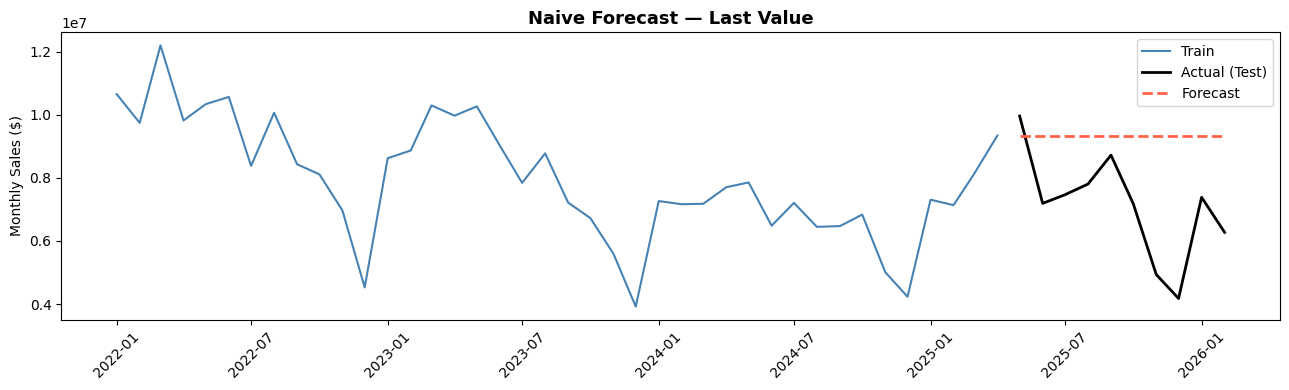


  Model : Naive — Seasonal (Same Month Last Year)
  MAE   : $810,162
  RMSE  : $1,130,751
  MAPE  : 10.02%


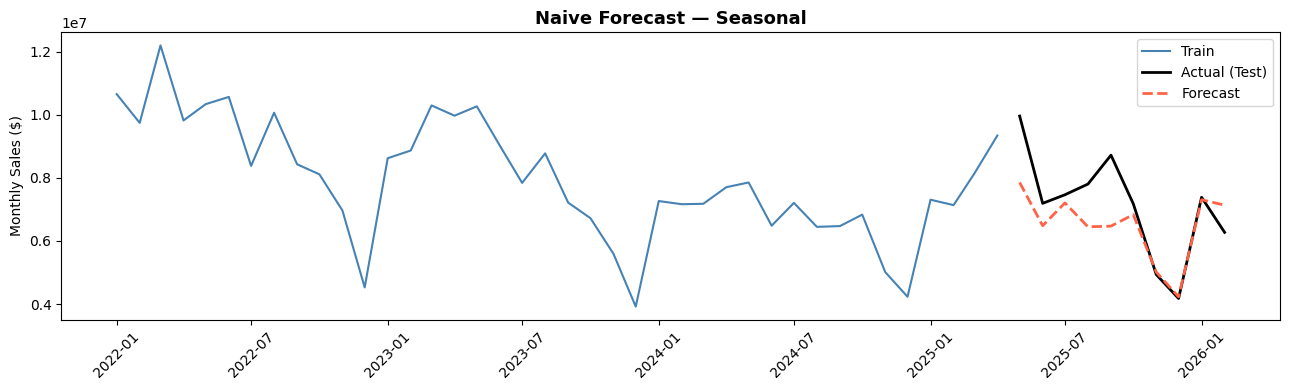

In [5]:
# ── MODEL 1A: LAST VALUE NAIVE ────────────────────────────────────
last_val = train['Sales'].iloc[-1]
preds_last = np.full(len(test), last_val)

res = evaluate(test['Sales'].values, preds_last, "Naive — Last Value")
results_log.append(res)
plot_forecast(train, test, preds_last, "Naive Forecast — Last Value")

# ── MODEL 1B: SEASONAL NAIVE (same month last year) ───────────────
preds_seasonal = []
for dt in test.index:
    prior_year = dt - pd.DateOffset(years=1)
    if prior_year in train.index:
        preds_seasonal.append(train.loc[prior_year, 'Sales'])
    else:
        preds_seasonal.append(train['Sales'].iloc[-1])  # fallback

res = evaluate(test['Sales'].values, preds_seasonal, "Naive — Seasonal (Same Month Last Year)")
results_log.append(res)
plot_forecast(train, test, preds_seasonal, "Naive Forecast — Seasonal")

## Model 2 — Moving Average

Two variants:
- **Simple Moving Average (SMA)**: equal weight over last N periods
- **Weighted Moving Average (WMA)**: linearly more weight to recent periods


  Model : Simple Moving Average (window=3)
  MAE   : $1,599,142
  RMSE  : $1,789,158
  MAPE  : 25.90%


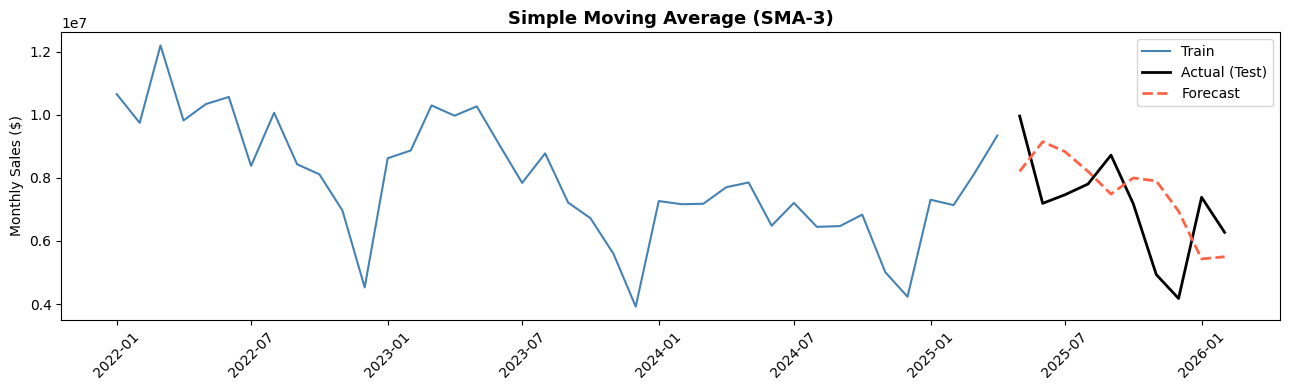


  Model : Weighted Moving Average (window=3)
  MAE   : $1,464,572
  RMSE  : $1,711,979
  MAPE  : 23.46%


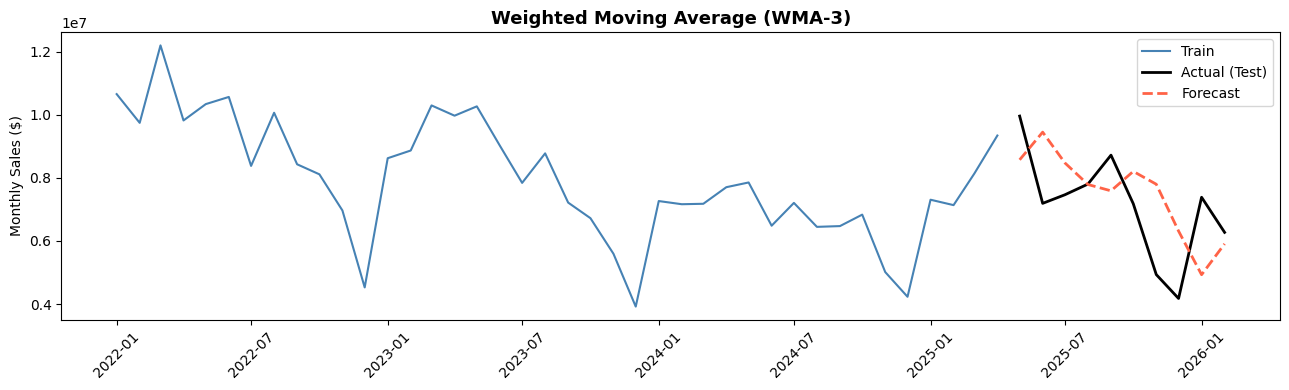

In [6]:
# ── MODEL 2A: SIMPLE MOVING AVERAGE ──────────────────────────────
window = 3   # 3-month SMA
full_series = monthly['Sales'].copy()

preds_sma = []
for i in range(len(test)):
    # use only data before this test point
    history = full_series.iloc[:split_idx + i]
    preds_sma.append(history.iloc[-window:].mean())

res = evaluate(test['Sales'].values, preds_sma, f"Simple Moving Average (window={window})")
results_log.append(res)
plot_forecast(train, test, preds_sma, f"Simple Moving Average (SMA-{window})")

# ── MODEL 2B: WEIGHTED MOVING AVERAGE ────────────────────────────
preds_wma = []
for i in range(len(test)):
    history = full_series.iloc[:split_idx + i].iloc[-window:]
    weights  = np.arange(1, len(history) + 1, dtype=float)
    wma_val  = np.dot(history.values, weights) / weights.sum()
    preds_wma.append(wma_val)

res = evaluate(test['Sales'].values, preds_wma, f"Weighted Moving Average (window={window})")
results_log.append(res)
plot_forecast(train, test, preds_wma, f"Weighted Moving Average (WMA-{window})")

## Model 3 — Simple Exponential Smoothing (SES)

Gives exponentially more weight to recent observations. Best for data with **no trend, no seasonality**.


  Model : Simple Exponential Smoothing (SES)
  MAE   : $1,944,112
  RMSE  : $2,344,213
  MAPE  : 34.01%
  Optimal alpha (smoothing level): 0.6773


/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


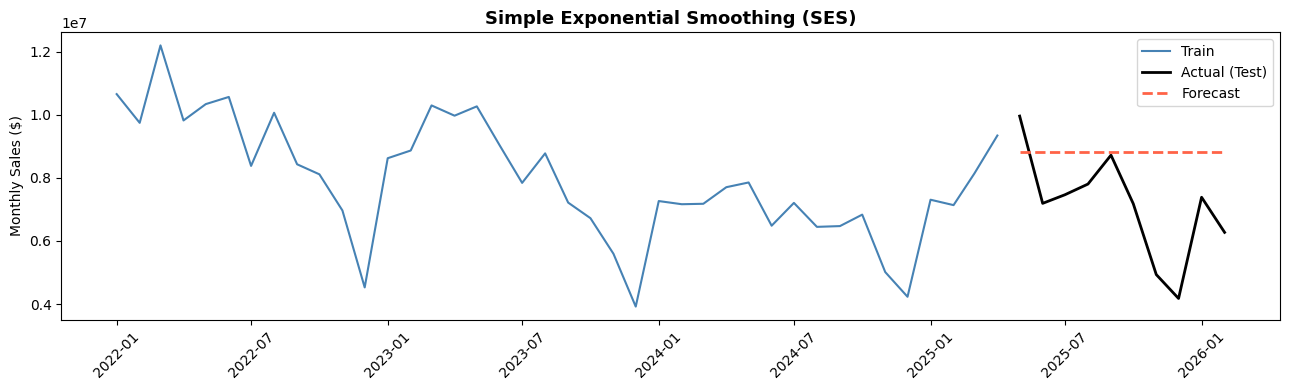

In [7]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit on train, forecast test length
ses_model = SimpleExpSmoothing(train['Sales'], initialization_method='estimated')
ses_fit   = ses_model.fit(optimized=True)
preds_ses = ses_fit.forecast(len(test))

res = evaluate(test['Sales'].values, preds_ses.values, "Simple Exponential Smoothing (SES)")
results_log.append(res)
print(f"  Optimal alpha (smoothing level): {ses_fit.model.params['smoothing_level']:.4f}")
plot_forecast(train, test, preds_ses.values, "Simple Exponential Smoothing (SES)")

## Model 4 — Holt-Winters Exponential Smoothing

Handles **trend + seasonality**. Most powerful of the exponential smoothing family.

/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



  Model : Holt-Winters (additive trend + seasonality)
  MAE   : $789,040
  RMSE  : $956,151
  MAPE  : 11.21%


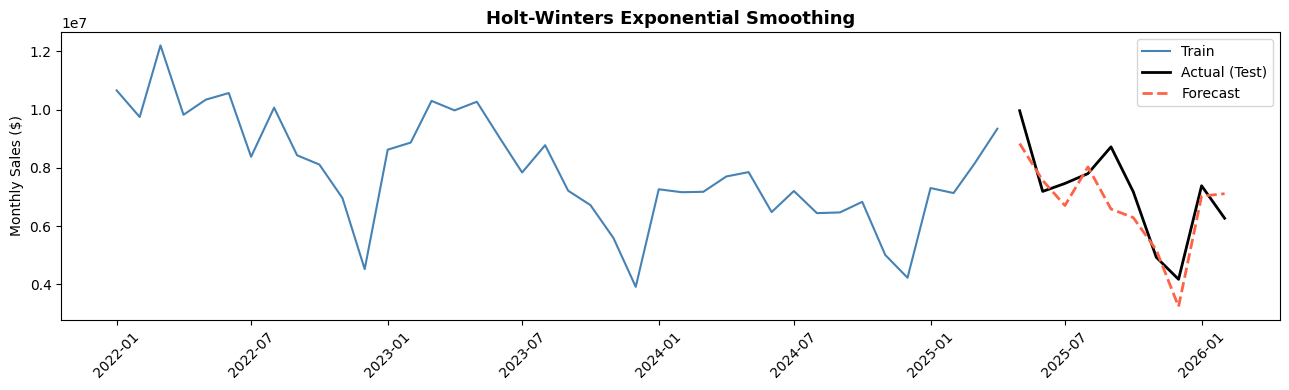

/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



  Model : Holt-Winters (additive trend + multiplicative seasonality)
  MAE   : $1,206,969
  RMSE  : $1,402,873
  MAPE  : 18.13%


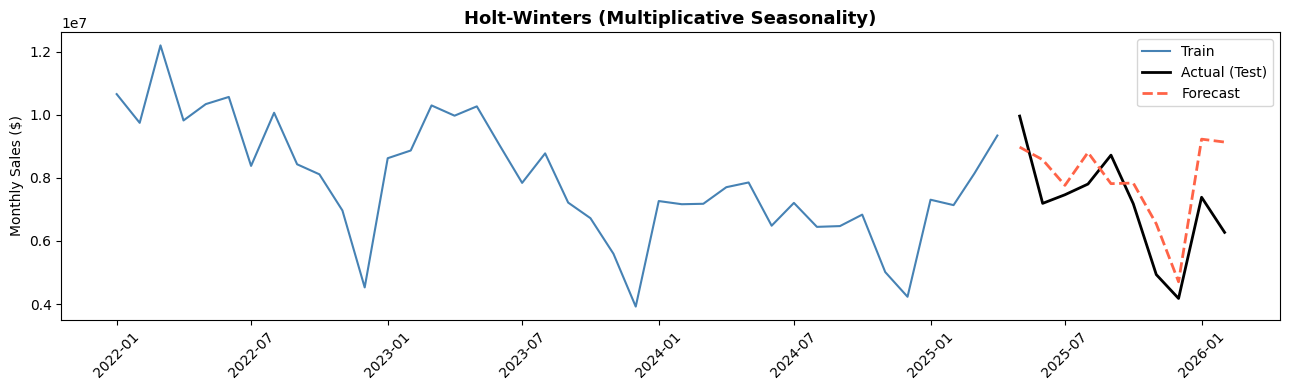

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Additive trend + additive seasonality (monthly → period=12)
hw_model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
)
hw_fit   = hw_model.fit(optimized=True)
preds_hw = hw_fit.forecast(len(test))

res = evaluate(test['Sales'].values, preds_hw.values, "Holt-Winters (additive trend + seasonality)")
results_log.append(res)
plot_forecast(train, test, preds_hw.values, "Holt-Winters Exponential Smoothing")

# Multiplicative variant for comparison
hw_mul = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
)
hw_mul_fit   = hw_mul.fit(optimized=True)
preds_hw_mul = hw_mul_fit.forecast(len(test))

res = evaluate(test['Sales'].values, preds_hw_mul.values, "Holt-Winters (additive trend + multiplicative seasonality)")
results_log.append(res)
plot_forecast(train, test, preds_hw_mul.values, "Holt-Winters (Multiplicative Seasonality)")

## Model 5 — ARIMA

AutoRegressive Integrated Moving Average. Uses past values and past errors.
- **AR(p)**: lag observations
- **I(d)**: differencing to make series stationary
- **MA(q)**: lag forecast errors

We use `auto_arima` from pmdarima to automatically find the best (p,d,q).


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


Best ARIMA order: (0, 1, 0)

  Model : ARIMA(0, 1, 0)
  MAE   : $2,357,096
  RMSE  : $2,745,004
  MAPE  : 40.67%


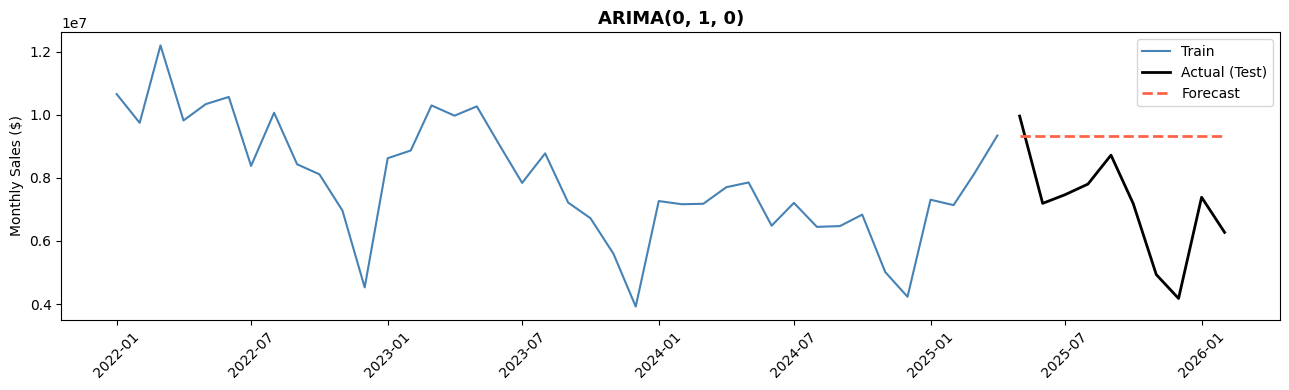

In [9]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'])

from pmdarima import auto_arima

arima_model = auto_arima(
    train['Sales'],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic'
)
print(f"Best ARIMA order: {arima_model.order}")

preds_arima = arima_model.predict(n_periods=len(test))

res = evaluate(test['Sales'].values, preds_arima, f"ARIMA{arima_model.order}")
results_log.append(res)
plot_forecast(train, test, preds_arima, f"ARIMA{arima_model.order}")

## Model 6 — SARIMA (Seasonal ARIMA)

Extends ARIMA with seasonal components (P, D, Q, m). Better suited for monthly sales with yearly seasonality (m=12).

Best SARIMA order: (1, 1, 0)  seasonal: (1, 0, 0, 12)

  Model : SARIMA(1, 1, 0)x(1, 0, 0, 12)
  MAE   : $1,671,091
  RMSE  : $1,938,457
  MAPE  : 28.51%


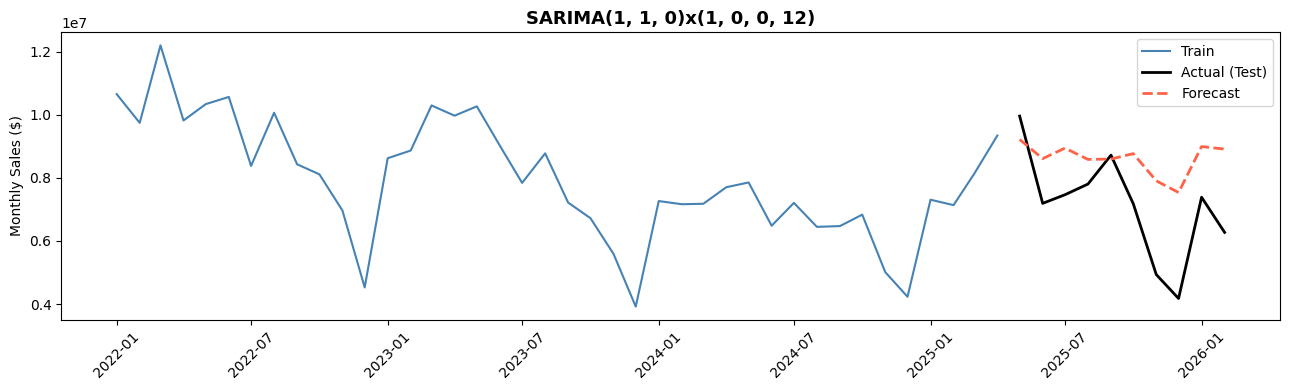

In [10]:
sarima_model = auto_arima(
    train['Sales'],
    seasonal=True,
    m=12,               # monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic',
    max_p=3, max_q=3,
    max_P=2, max_Q=2
)
print(f"Best SARIMA order: {sarima_model.order}  seasonal: {sarima_model.seasonal_order}")

preds_sarima = sarima_model.predict(n_periods=len(test))

res = evaluate(test['Sales'].values, preds_sarima, f"SARIMA{sarima_model.order}x{sarima_model.seasonal_order}")
results_log.append(res)
plot_forecast(train, test, preds_sarima, f"SARIMA{sarima_model.order}x{sarima_model.seasonal_order}")

## Model 7 — Linear Regression with Time Features

Treats the forecasting problem as supervised ML. Engineers time-based features (trend, month dummies, lag features) and fits a regression model.

## Feature Engineering — Using All Columns from SalesData_ATW.xlsx

Now we build monthly features from every column: product lines, warehouses, customers, quantities, COGS, return rates, and more.

In [11]:
# ── RELOAD RAW DATA & BUILD RICH MONTHLY FEATURES ────────────────
raw = pd.read_excel('/Users/manuhalapeth/Kenda/SalesData_ATW.xlsx', engine='openpyxl')

# Clean
raw = raw[(raw['DollarsSold'] != 0) | (raw['QuantityShipped'] != 0)]
raw = raw[raw['QuantityReturned'] >= 0]
raw['Month'] = raw['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

# ── Aggregate all features monthly ───────────────────────────────
agg = raw.groupby('Month').agg(
    Sales            = ('DollarsSold',      'sum'),
    COGS             = ('CostOfGoodsSold',  'sum'),
    QtyShipped       = ('QuantityShipped',  'sum'),
    QtyReturned      = ('QuantityReturned', 'sum'),
    NumTransactions  = ('DollarsSold',      'count'),
    NumCustomers     = ('CustomerNo',       'nunique'),
    NumItems         = ('ItemCode',         'nunique'),
    NumWarehouses    = ('WarehouseCode',    'nunique'),
    AvgOrderValue    = ('DollarsSold',      'mean'),
    MaxOrderValue    = ('DollarsSold',      'max'),
).reset_index().set_index('Month').sort_index()

# Derived features
agg['GrossMargin']   = (agg['Sales'] - agg['COGS']) / agg['Sales'].replace(0, 1)
agg['ReturnRate']    = agg['QtyReturned'] / agg['QtyShipped'].replace(0, 1)

# Product line sales share per month
pl_monthly = raw.groupby(['Month', 'ProductLine'])['DollarsSold'].sum().unstack(fill_value=0)
pl_share   = pl_monthly.div(pl_monthly.sum(axis=1), axis=0)
pl_share.columns = [f'PL_{c}_share' for c in pl_share.columns]
agg = agg.join(pl_share, how='left').fillna(0)

# Warehouse concentration (Herfindahl index — 1=one warehouse, low=distributed)
wh_monthly = raw.groupby(['Month', 'WarehouseCode'])['DollarsSold'].sum().unstack(fill_value=0)
wh_share   = wh_monthly.div(wh_monthly.sum(axis=1), axis=0)
agg['WHConcentration'] = (wh_share ** 2).sum(axis=1)

print(f"Monthly feature matrix: {agg.shape[0]} rows x {agg.shape[1]} columns")
print("\nFeatures:", list(agg.columns))
print("\nSample:")
print(agg.head(3).to_string())


Monthly feature matrix: 50 rows x 22 columns

Features: ['Sales', 'COGS', 'QtyShipped', 'QtyReturned', 'NumTransactions', 'NumCustomers', 'NumItems', 'NumWarehouses', 'AvgOrderValue', 'MaxOrderValue', 'GrossMargin', 'ReturnRate', 'PL_0001_share', 'PL_0002_share', 'PL_0003_share', 'PL_0004_share', 'PL_0006_share', 'PL_0007_share', 'PL_0008_share', 'PL_0500_share', 'PL_CUST_share', 'WHConcentration']

Sample:
                  Sales        COGS  QtyShipped  QtyReturned  NumTransactions  NumCustomers  NumItems  NumWarehouses  AvgOrderValue  MaxOrderValue  GrossMargin  ReturnRate  PL_0001_share  PL_0002_share  PL_0003_share  PL_0004_share  PL_0006_share  PL_0007_share  PL_0008_share  PL_0500_share  PL_CUST_share  WHConcentration
Month                                                                                                                                                                                                                                                                    

## Train/Test Split on Rich Feature Set

In [12]:
split_idx2 = int(len(agg) * 0.8)
train2 = agg.iloc[:split_idx2]
test2  = agg.iloc[split_idx2:]

feat_cols2 = [c for c in agg.columns if c != 'Sales']

# Add time features
def add_time_features(df):
    df = df.copy()
    df['trend']   = range(len(df))
    df['month']   = df.index.month
    df['quarter'] = df.index.quarter
    # Lag sales
    df['lag_1']   = df['Sales'].shift(1)
    df['lag_2']   = df['Sales'].shift(2)
    df['lag_3']   = df['Sales'].shift(3)
    df['lag_12']  = df['Sales'].shift(12)
    df['roll_3']  = df['Sales'].shift(1).rolling(3).mean()
    df['roll_6']  = df['Sales'].shift(1).rolling(6).mean()
    return df

agg_feat = add_time_features(agg)
agg_feat = pd.get_dummies(agg_feat, columns=['month'], drop_first=True, dtype=float)

all_feat_cols = [c for c in agg_feat.columns if c != 'Sales']

train_f = agg_feat.iloc[:split_idx2].dropna()
test_f  = agg_feat.iloc[split_idx2:].dropna()

X_train2, y_train2 = train_f[all_feat_cols], train_f['Sales']
X_test2,  y_test2  = test_f[all_feat_cols],  test_f['Sales']

print(f"Train: {train2.index[0].strftime('%Y-%m')} → {train2.index[-1].strftime('%Y-%m')} ({len(train2)} months)")
print(f"Test:  {test2.index[0].strftime('%Y-%m')} → {test2.index[-1].strftime('%Y-%m')} ({len(test2)} months)")
print(f"Feature count: {len(all_feat_cols)}")


Train: 2022-01 → 2025-04 (40 months)
Test:  2025-05 → 2026-02 (10 months)
Feature count: 40


## Model 7 — Linear Regression (All Features)

Now includes product line shares, warehouse concentration, customer counts, COGS, return rates, and lag features.


  Model : Linear Regression (all features)
  MAE   : $533,504
  RMSE  : $679,561
  MAPE  : 7.62%


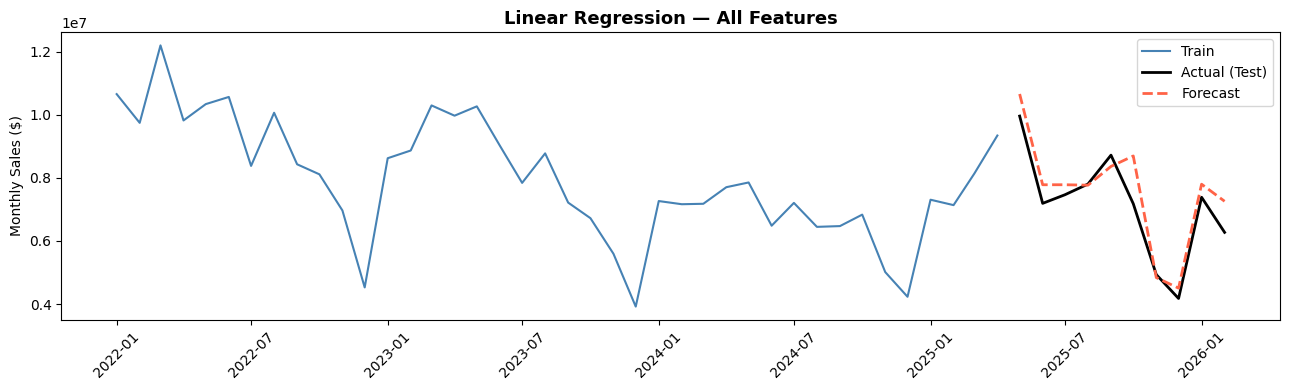


Top 10 features by coefficient magnitude:
GrossMargin      2.924722e+06
PL_0002_share    1.611824e+06
month_6          1.385274e+06
PL_0003_share    8.964848e+05
month_4          6.826668e+05
month_12         6.825785e+05
month_5          6.772521e+05
month_10         6.050014e+05
month_8          5.917138e+05
month_3          5.120107e+05


In [13]:
from sklearn.linear_model import LinearRegression

lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)
preds_lr2 = lr2.predict(X_test2)

test_aligned2 = test_f[['Sales']]
res = evaluate(y_test2.values, preds_lr2, "Linear Regression (all features)")
results_log.append(res)
plot_forecast(train2, test_aligned2, preds_lr2, "Linear Regression — All Features")

print("\nTop 10 features by coefficient magnitude:")
coef_df = pd.Series(lr2.coef_, index=all_feat_cols).abs().sort_values(ascending=False).head(10)
print(coef_df.to_string())


## Model 8 — Random Forest (All Features)

Ensemble of trees with full feature set including product lines, warehouses, and customer dynamics.


  Model : Random Forest (all features)
  MAE   : $217,249
  RMSE  : $271,570
  MAPE  : 3.54%


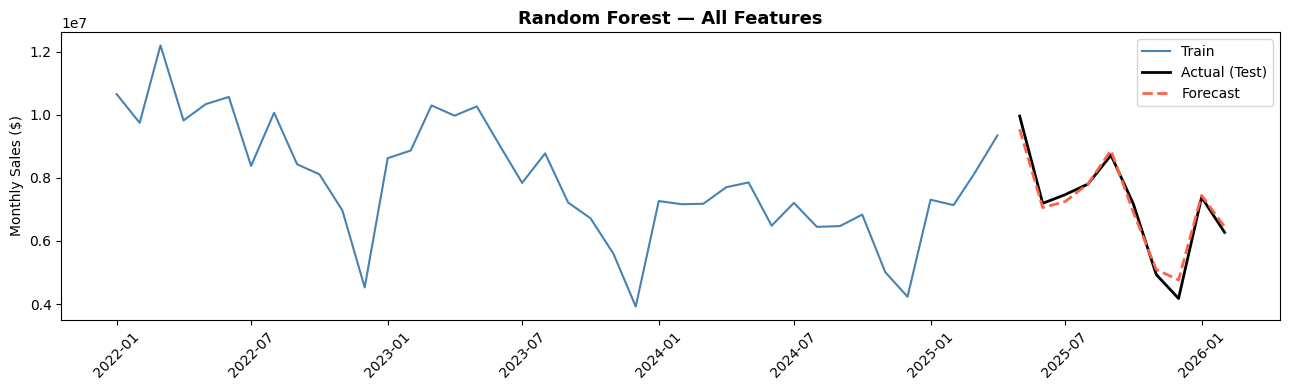


Top 10 feature importances:
COGS               0.538898
QtyShipped         0.179251
NumTransactions    0.050882
NumCustomers       0.041672
NumItems           0.037691
lag_12             0.034945
trend              0.021509
quarter            0.013746
AvgOrderValue      0.010692
lag_1              0.007876


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf2 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
preds_rf2 = rf2.predict(X_test2)

res = evaluate(y_test2.values, preds_rf2, "Random Forest (all features)")
results_log.append(res)
plot_forecast(train2, test_aligned2, preds_rf2, "Random Forest — All Features")

print("\nTop 10 feature importances:")
fi = pd.Series(rf2.feature_importances_, index=all_feat_cols).sort_values(ascending=False).head(10)
print(fi.to_string())


## Model 9 — XGBoost (All Features)

Gradient boosting with the full feature set. Should significantly outperform the time-features-only version.


  Model : XGBoost (all features)
  MAE   : $238,336
  RMSE  : $312,488
  MAPE  : 3.75%


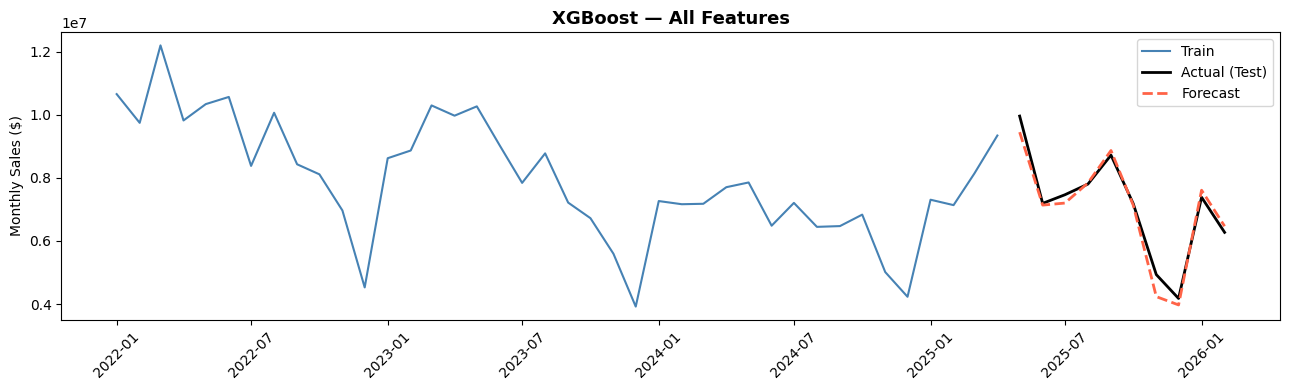


Top 10 feature importances:
trend              0.407159
COGS               0.251788
QtyShipped         0.077060
NumTransactions    0.068801
roll_6             0.039236
lag_1              0.030762
quarter            0.030619
NumCustomers       0.016008
AvgOrderValue      0.012571
month_10           0.011628


In [15]:
from xgboost import XGBRegressor

xgb2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb2.fit(X_train2, y_train2, eval_set=[(X_test2, y_test2)], verbose=False)
preds_xgb2 = xgb2.predict(X_test2)

res = evaluate(y_test2.values, preds_xgb2, "XGBoost (all features)")
results_log.append(res)
plot_forecast(train2, test_aligned2, preds_xgb2, "XGBoost — All Features")

print("\nTop 10 feature importances:")
fi_xgb = pd.Series(xgb2.feature_importances_, index=all_feat_cols).sort_values(ascending=False).head(10)
print(fi_xgb.to_string())


## Model 10 — Prophet with External Regressors

Prophet supports additional regressors alongside the time series. We add COGS, customer count, quantity shipped, and product line shares as regressors.

Importing plotly failed. Interactive plots will not work.


14:04:24 - cmdstanpy - INFO - Chain [1] start processing
14:04:38 - cmdstanpy - INFO - Chain [1] done processing



  Model : Prophet (with external regressors)
  MAE   : $759,857
  RMSE  : $847,260
  MAPE  : 11.52%


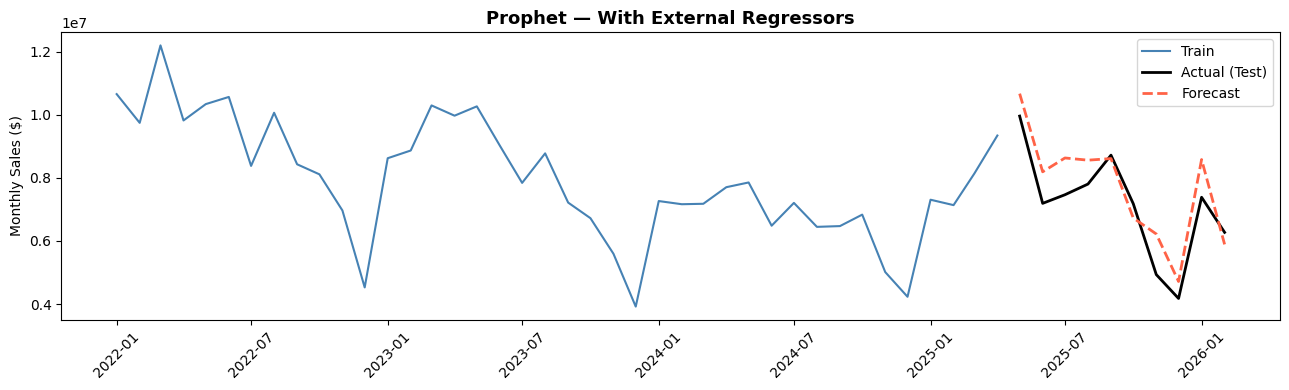

In [16]:
from prophet import Prophet

regressor_cols = ['COGS', 'NumCustomers', 'QtyShipped', 'ReturnRate', 'GrossMargin',
                  'NumTransactions', 'NumItems'] + [c for c in agg.columns if 'PL_' in c]

prophet_df = agg[['Sales'] + regressor_cols].reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})

train_p2 = prophet_df.iloc[:split_idx2]
test_p2  = prophet_df.iloc[split_idx2:]

m2 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
for col in regressor_cols:
    m2.add_regressor(col)

m2.fit(train_p2)

future2 = test_p2[['ds'] + regressor_cols].copy()
forecast2 = m2.predict(future2)
preds_prophet2 = forecast2['yhat'].values

res = evaluate(test_p2['y'].values, preds_prophet2, "Prophet (with external regressors)")
results_log.append(res)
plot_forecast(train2, test2, preds_prophet2, "Prophet — With External Regressors")


## Final Model Comparison — All Models


         FINAL MODEL ACCURACY COMPARISON (ranked by MAPE)
                                                         Model         MAE        RMSE    MAPE
1                                 Random Forest (all features)    $217,249    $271,570   3.54%
2                                       XGBoost (all features)    $238,336    $312,488   3.75%
3                             Linear Regression (all features)    $533,504    $679,561   7.62%
4                      Naive — Seasonal (Same Month Last Year)    $810,162  $1,130,751  10.02%
5                  Holt-Winters (additive trend + seasonality)    $789,040    $956,151  11.21%
6                           Prophet (with external regressors)    $759,857    $847,260  11.52%
7   Holt-Winters (additive trend + multiplicative seasonality)  $1,206,969  $1,402,873  18.13%
8                           Weighted Moving Average (window=3)  $1,464,572  $1,711,979  23.46%
9                             Simple Moving Average (window=3)  $1,599,142  $1,789,158

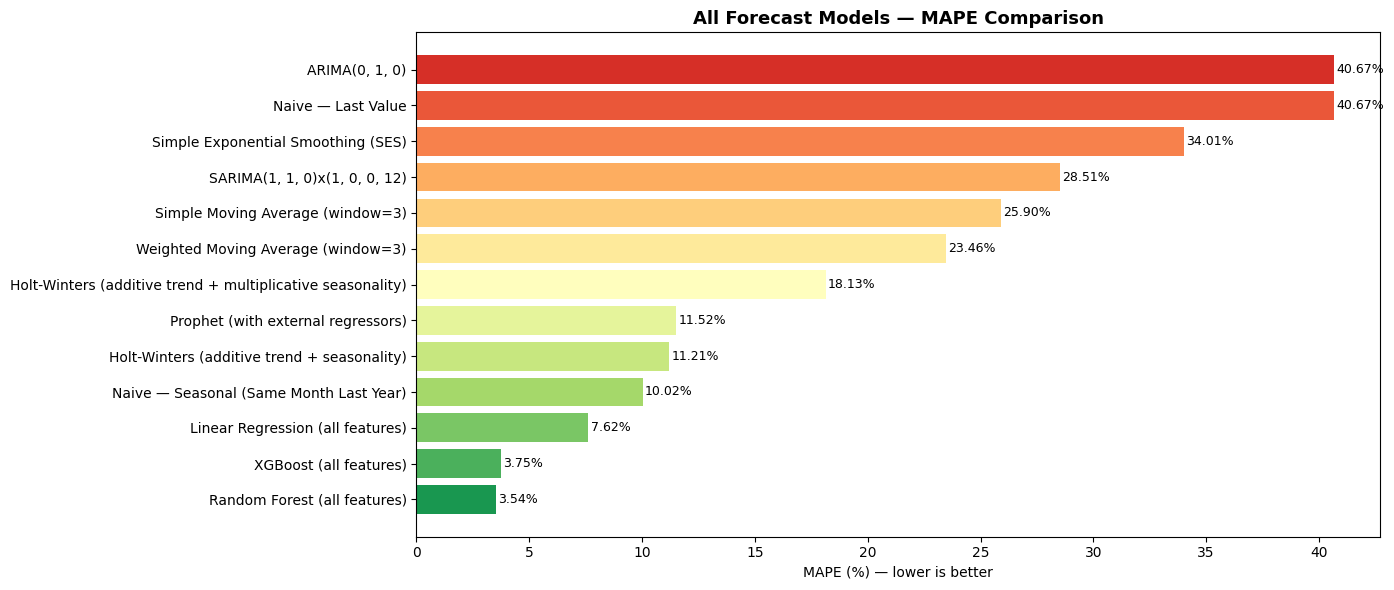

In [17]:
summary = pd.DataFrame(results_log).sort_values('MAPE').reset_index(drop=True)
summary.index += 1

display_df = summary.copy()
display_df['MAE']  = display_df['MAE'].map('${:,.0f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('${:,.0f}'.format)
display_df['MAPE'] = display_df['MAPE'].map('{:.2f}%'.format)

print("\n" + "="*70)
print("         FINAL MODEL ACCURACY COMPARISON (ranked by MAPE)")
print("="*70)
print(display_df[['Model', 'MAE', 'RMSE', 'MAPE']].to_string())
print("="*70)

# Bar chart
mape_vals   = summary['MAPE'].tolist()
model_names = summary['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(mape_vals)))
bars = ax.barh(model_names, mape_vals, color=colors)
ax.set_xlabel('MAPE (%) — lower is better')
ax.set_title('All Forecast Models — MAPE Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars, mape_vals):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
